In [ ]:
# ---------------------------------------------------------
# 1. SETUP & IMPORTS
# ---------------------------------------------------------
import uuid
import os
from typing import List, Literal, Optional
from dotenv import load_dotenv

# LangChain & LangGraph
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage, AIMessage
from langchain_core.runnables import RunnableConfig
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.postgres import PostgresStore
from langgraph.checkpoint.postgres import PostgresSaver
from psycopg_pool import ConnectionPool

# Load API Keys
load_dotenv()

# Define the Database Connection String (Update with your credentials)
# Ensure you have a running Postgres instance.
DB_URI = os.getenv("LTM_DB_URL")

In [2]:
# ---------------------------------------------------------
# 2. DEFINING SCHEMAS & STATE
# ---------------------------------------------------------

# --- A. LTM (Long Term Memory) Operations Schema ---
class MemoryOp(BaseModel):
    """Operation to modify the user's long-term profile."""
    action: Literal["create", "update", "delete"] = Field(
        description="Action: 'create' for new facts, 'update' to correct existing ones, 'delete' for obsolete ones."
    )
    memory_id: Optional[str] = Field(
        default=None, 
        description="The UUID of the specific memory item (required for update/delete)."
    )
    content: Optional[str] = Field(
        default=None, 
        description="The fact text (required for create/update)."
    )

class MemoryOutput(BaseModel):
    thoughts: str = Field(description="Reasoning behind the memory changes.")
    operations: List[MemoryOp] = Field(default_factory=list)

# --- B. The Graph State (Hybrid Memory) ---
class AgentState(MessagesState):
    summary: str      # STM: Summary of conversation
    user_profile: str # LTM: User details fetched from DB

In [3]:
# ---------------------------------------------------------
# 3. LLM & PROMPT CONFIGURATION
# ---------------------------------------------------------

# --- Models ---
# Fast model for Chat & Summarization
fast_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
# Smart model for Memory Logic (Precision is key here)
smart_llm = ChatOpenAI(model="gpt-4o", temperature=0)

# --- Prompts ---

# 1. LTM Manager Prompt
MEMORY_SYSTEM_PROMPT = """You are a Memory Manager.
Your job is to maintain a factual User Profile based on the conversation.

CURRENT PROFILE (with IDs):
{existing_memories}

LATEST USER MESSAGE:
"{user_message}"

INSTRUCTIONS:
- Analyze the user's message.
- If they state a NEW fact (e.g., "I like red"), output action='create'.
- If they CHANGE a fact (e.g., "Actually, I like blue now"), output action='update' targeting the old memory's ID.
- If they correct a wrong fact, output action='delete' or 'update'.
- Ignore transient chatter (e.g., "Hello", "Thanks").
"""

# 2. STM Summarizer Prompt
SUMMARY_PROMPT = """You are a Conversation Summarizer.
Extend the existing summary with the new lines of conversation.
Keep it concise but retain key details essential for context.

Existing Summary:
{existing_summary}

New Lines to Add:
{new_lines}
"""

# 3. Main Chat "Sandwich" Prompt
CHAT_SYSTEM_PROMPT = """You are a personalized assistant.

### 1. LONG-TERM MEMORY (User Profile)
{user_profile}

### 2. SHORT-TERM CONTEXT (Conversation Summary)
{summary}

### INSTRUCTIONS
- Use the User Profile to personalize your greeting and answers.
- Use the Conversation Summary to understand what we just talked about.
- Answer the user's latest message naturally.
"""

In [4]:
# ---------------------------------------------------------
# 4. NODE: MANAGE LTM (CORRECTED)
# ---------------------------------------------------------
def ltm_node(state: AgentState, config: RunnableConfig, *, store: PostgresStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "profile")
    
    # 1. Fetch Existing Memories (To show to LLM)
    items = store.search(namespace)
    existing_text = ""
    if items:
        for item in items:
            existing_text += f"ID: {item.key} | Fact: {item.value['data']}\n"
    else:
        existing_text = "(Empty Profile)"

    # 2. Run LLM Logic (Skip if bot is speaking)
    last_msg = state["messages"][-1]
    if isinstance(last_msg, HumanMessage):
        extractor = smart_llm.with_structured_output(MemoryOutput)
        decision = extractor.invoke([
            SystemMessage(content=MEMORY_SYSTEM_PROMPT.format(
                existing_memories=existing_text, 
                user_message=last_msg.content
            ))
        ])

        # 3. Execute Updates
        if decision.operations:
            print(f"\n🧠 [LTM UPDATE] {decision.thoughts}")
            for op in decision.operations:
                if op.action == "create" and op.content:
                    store.put(namespace, str(uuid.uuid4()), {"data": op.content})
                elif op.action == "update" and op.memory_id and op.content:
                    store.put(namespace, op.memory_id, {"data": op.content})
                elif op.action == "delete" and op.memory_id:
                    store.delete(namespace, op.memory_id)
            
            # 4. RE-FETCH updated memories to pass to the Chat Node
            # We fetch again to ensure the Chat Node sees the very latest data
            items = store.search(namespace)
            existing_text = "\n".join([f"- {i.value['data']}" for i in items])
    
    # Return the text to the State
    return {"user_profile": existing_text}

In [5]:
# ---------------------------------------------------------
# 5. NODE: CHAT GENERATION (CORRECTED)
# ---------------------------------------------------------
def chat_node(state: AgentState, config: RunnableConfig, *, store: PostgresStore):
    
    # 1. Read LTM from State (Passed by ltm_node)
    # Default to "No details" if empty
    profile_text = state.get("user_profile", "No known user details.")

    # 2. Read STM from State
    current_summary = state.get("summary", "No summary yet.")

    # 3. Construct Sandwich Prompt
    system_msg = SystemMessage(content=CHAT_SYSTEM_PROMPT.format(
        user_profile=profile_text,
        summary=current_summary
    ))

    # 4. Generate Response
    response = fast_llm.invoke([system_msg] + state["messages"])
    
    return {"messages": [response]}

In [6]:
# ---------------------------------------------------------
# 6. NODE: STM SUMMARIZER (Context Pruning)
# ---------------------------------------------------------
def summarize_node(state: AgentState):
    """
    Checks if message history is too long. 
    If yes, summarizes the oldest messages and deletes them.
    """
    messages = state["messages"]
    summary = state.get("summary", "")

    # Rule: Summarize if we have more than 6 messages (3 turns)
    if len(messages) > 6:
        print("\n🧹 [STM CLEANUP] Summarizing conversation...")
        
        # We'll summarize all but the last 2 messages (Keep strictly recent context)
        to_summarize = messages[:-2] 
        
        # Create prompt
        prompt = SUMMARY_PROMPT.format(
            existing_summary=summary if summary else "None",
            new_lines="\n".join([f"{m.type}: {m.content}" for m in to_summarize])
        )
        
        # Generate new summary
        new_summary_msg = fast_llm.invoke(prompt)
        
        # Return state update: 
        # 1. Update summary
        # 2. Delete the messages we just summarized
        return {
            "summary": new_summary_msg.content,
            "messages": [RemoveMessage(id=m.id) for m in to_summarize]
        }
    
    return {}

In [7]:
# ---------------------------------------------------------
# 7. BUILD THE PRODUCTION GRAPH (FIXED)
# ---------------------------------------------------------
from functools import partial # <--- IMPORTANT IMPORT

# 1. Setup the connection pool
pool = ConnectionPool(conninfo=DB_URI, max_size=20, kwargs={"autocommit": True})

# 2. Initialize the Store (LTM) and Checkpointer (STM)
store = PostgresStore(pool)
store.setup()

checkpointer = PostgresSaver(pool)
checkpointer.setup()

# 3. Build Graph
builder = StateGraph(AgentState)

# --- CRITICAL FIX: Use partial to explicitly pass 'store' ---
# This ensures ltm_node(state, config, store=store) is called correctly
builder.add_node("ltm_manager", partial(ltm_node, store=store))
builder.add_node("chat_agent", partial(chat_node, store=store))

# Summarizer doesn't need 'store', so we add it normally
builder.add_node("stm_summarizer", summarize_node)

# 4. Define Edge Flow
builder.add_edge(START, "ltm_manager")
builder.add_edge("ltm_manager", "chat_agent")
builder.add_edge("chat_agent", "stm_summarizer")
builder.add_edge("stm_summarizer", END)

# 5. Compile (We still pass checkpointer, but store is now bound above)
graph = builder.compile(checkpointer=checkpointer)

print("✅ Production Graph Compiled Successfully (With Explicit Store Binding)!")

✅ Production Graph Compiled Successfully (With Explicit Store Binding)!


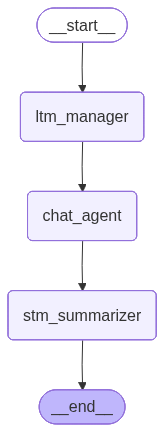

In [10]:
graph

In [8]:
# ---------------------------------------------------------
# 8. SIMULATION RUN
# ---------------------------------------------------------

# Configuration:
# user_id = unique user (Links to LTM)
# thread_id = unique conversation session (Links to STM)
config = {"configurable": {"user_id": "user_prod_01", "thread_id": "thread_A"}}

def run_chat(user_text):
    print(f"\n👤 USER: {user_text}")
    # We verify the thread_id to ensure STM persistence
    events = graph.stream(
        {"messages": [HumanMessage(content=user_text)]}, 
        config=config, 
        stream_mode="values"
    )
    for event in events:
        if "messages" in event:
            last_msg = event["messages"][-1]
            if isinstance(last_msg, AIMessage):
                # Print only the final response, avoiding intermediate steps
                print(f"🤖 BOT: {last_msg.content}")

# --- TURN 1: Introduction (Sets LTM) ---
run_chat("Hi, I'm Al Amin. I'm a Python Developer.")

# --- TURN 2: Follow up (Uses STM context) ---
run_chat("What did I just say my job was?")

# --- TURN 3: Correction (Updates LTM) ---
run_chat("Actually, I switched careers. I am a Rust Engineer now.")

# --- TURN 4: Verification (Checks updated LTM) ---
run_chat("Do you remember what I do for a living?")

# --- TURN 5-10: Flooding to trigger STM Summarization ---
# Sending filler messages to force the 'messages' list > 6
print("\n--- ⚡ RAPID FIRE TO TRIGGER SUMMARIZATION ⚡ ---")
run_chat("Tell me a short joke.")
run_chat("Another one.")
run_chat("One more.")
run_chat("What is my name again?")


👤 USER: Hi, I'm Al Amin. I'm a Python Developer.

🧠 [LTM UPDATE] The user introduced themselves as Al Amin and mentioned their profession as a Python Developer. These are new facts about the user that should be added to their profile.
🤖 BOT: Hi Al Amin! It's great to connect with a fellow Python Developer. How can I assist you today?

👤 USER: What did I just say my job was?
🤖 BOT: You mentioned that you are a Python Developer.

🧹 [STM CLEANUP] Summarizing conversation...
🤖 BOT: You mentioned that you are a Python Developer.

👤 USER: Actually, I switched careers. I am a Rust Engineer now.

🧠 [LTM UPDATE] The user has indicated a change in their career from being a Python Developer to a Rust Engineer. This requires updating the existing memory about their profession.
🤖 BOT: Got it, Al Amin! That's exciting to hear about your career switch to Rust engineering. If you need any assistance or have questions related to Rust, feel free to ask!

👤 USER: Do you remember what I do for a living?


In [9]:
# ---------------------------------------------------------
# 9. VERIFY PRODUCTION STATE
# ---------------------------------------------------------

print("\n🔍 --- INSPECTING DATABASE STATE ---")

# 1. Check LTM (User Profile)
print(f"\n📂 LTM (User Profile) in Postgres for 'user_prod_01':")
items = store.search(("user", "user_prod_01", "profile"))
for item in items:
    print(f"   - [ID: {item.key[:8]}] {item.value['data']}")

# 2. Check STM (Active Summary)
print(f"\n📝 STM (Current Thread Summary) in Checkpointer:")
# We fetch the latest state from the checkpointer
current_state = graph.get_state(config)
print(f"   - Summary: {current_state.values.get('summary', 'None')}")
print(f"   - Active Message Count: {len(current_state.values.get('messages', []))}")


🔍 --- INSPECTING DATABASE STATE ---

📂 LTM (User Profile) in Postgres for 'user_prod_01':
   - [ID: cc9835bd] User is a Rust Engineer.
   - [ID: cadbd0e2] User's name is Al Amin.

📝 STM (Current Thread Summary) in Checkpointer:
   - Summary: Summary:
Al Amin introduces himself as a Python Developer, but later reveals he has switched careers to become a Rust Engineer. The AI expresses enthusiasm for the switch and offers assistance with any Rust-related questions. The conversation shifts to humor, with the AI sharing jokes about programming: why programmers prefer dark mode (because light attracts bugs), why Rust programmers carry a pencil (in case they need to "draw" their ownership), and why a developer went broke (because he used up all his cache).
   - Active Message Count: 2
